In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load dataset
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/latest/owid-covid-latest.csv"
df = pd.read_csv(url)

# Select relevant columns
data = df[['total_deaths_per_million', 'total_cases_per_million', 'people_fully_vaccinated_per_hundred']].dropna()

# Define variables
X = data[['total_cases_per_million', 'people_fully_vaccinated_per_hundred']]
y = data['total_deaths_per_million']

# Add constant and fit linear regression
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print()
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     total_deaths_per_million   R-squared:                       0.703
Model:                                  OLS   Adj. R-squared:                  0.649
Method:                       Least Squares   F-statistic:                     12.99
Date:                      Thu, 09 Oct 2025   Prob (F-statistic):            0.00127
Time:                              14:28:02   Log-Likelihood:                -110.90
No. Observations:                        14   AIC:                             227.8
Df Residuals:                            11   BIC:                             229.7
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  res = hypotest_fun_out(*samples, **kwds)


Non-Linear Regression (Polynomial Degree = 2)
RMSE: 627.530
R²: 0.737
Number of features (including polynomial terms): 5


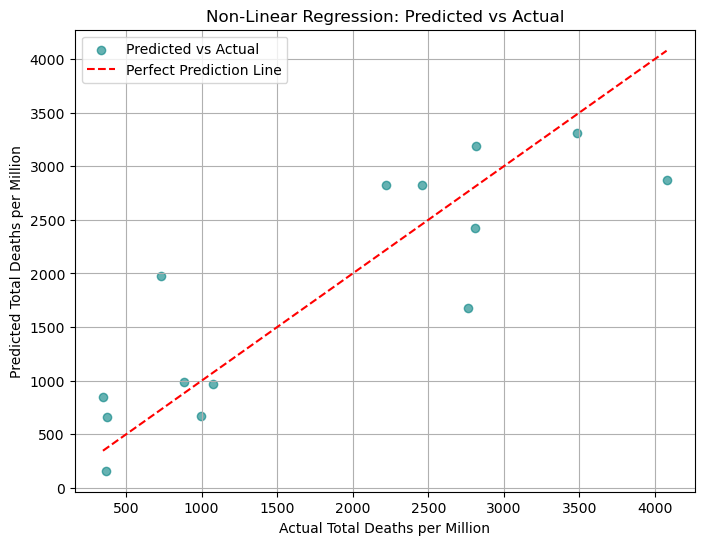


Polynomial Feature Names:
['total_cases_per_million' 'people_fully_vaccinated_per_hundred'
 'total_cases_per_million^2'
 'total_cases_per_million people_fully_vaccinated_per_hundred'
 'people_fully_vaccinated_per_hundred^2']


In [3]:
# Non-Linear Regression (Polynomial Regression) using OWID COVID-19 Data
# Dataset: https://github.com/owid/covid-19-data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load dataset
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/latest/owid-covid-latest.csv"
df = pd.read_csv(url)

# Step 2: Select variables of interest
data = df[["total_deaths_per_million", "total_cases_per_million", "people_fully_vaccinated_per_hundred"]].dropna()

# Step 3: Define X and y variables
X = data[["total_cases_per_million", "people_fully_vaccinated_per_hundred"]]
y = data["total_deaths_per_million"]

# Step 4: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Create Polynomial (Non-Linear) Features – degree = 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# Step 6: Fit Non-Linear Regression Model
model = LinearRegression()
model.fit(X_poly, y)

# Step 7: Predictions
y_pred = model.predict(X_poly)

# Step 8: Evaluate Model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Non-Linear Regression (Polynomial Degree = 2)")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print(f"Number of features (including polynomial terms): {X_poly.shape[1]}")

# Step 9: Visualization (Predicted vs Actual)
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.6, color='teal', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel("Actual Total Deaths per Million")
plt.ylabel("Predicted Total Deaths per Million")
plt.title("Non-Linear Regression: Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Show Polynomial Feature Names
print("\nPolynomial Feature Names:")
print(poly.get_feature_names_out(["total_cases_per_million", "people_fully_vaccinated_per_hundred"]))